In [1]:
from sklearn.metrics import classification_report, roc_auc_score, average_precision_score, confusion_matrix, accuracy_score
import xgboost as xgb
from sklearn.model_selection import train_test_split
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [16]:
merged_train = pd.read_csv('Merged_train_is_fraud.csv')
merged_test = pd.read_csv('Merged_Test_is_fraud.csv')


In [17]:
d = ['log_amt_y', 'merchant_txn_count_past_y',
       'merchant_unique_cards_past_y', 'card_txn_count_1h_y',
       'amt_to_card_median_y', 'amt_to_category_median_y', 'hour_of_day_y',
       'day_of_week_y', 'is_weekend_y', 'dist_home_merchant_km_y',
       'recency_sec_y', 'dist_prev_merchant_km_y', 'implied_speed_kmh_y', 'Var1_file2', 
       'amt_file2', 'city_pop_file2','unix_time_file2', 'merch_lat_file2', 'merch_long_file2',
       'lat_file2', 'long_file2', 'category',
       'cc_num', 'city', 'dob', 'first', 'gender', 'job', 'last',
       'merchant', 'state', 'street', 'trans_date_trans_time', 'zip', 'Var1']

merged_train = merged_train.drop(columns=d)

# merged_train.columns

In [18]:
for i in merged_train.columns:
      if i[-2:] == '_x' or i[-2:] == "_y":
            merged_train = merged_train.rename(columns={i: i[:-2]})
      
merged_train.columns

Index(['trans_num', 'amt', 'lat', 'long', 'city_pop', 'unix_time', 'merch_lat',
       'merch_long', 'log_amt', 'merchant_txn_count_past',
       'merchant_unique_cards_past', 'card_txn_count_1h', 'amt_to_card_median',
       'amt_to_category_median', 'hour_of_day', 'day_of_week', 'is_weekend',
       'dist_home_merchant_km', 'recency_sec', 'dist_prev_merchant_km',
       'implied_speed_kmh', 'StateFraudRate', 'AvgCardDist_km_', 'DistRatio',
       'LogDistance_km_', 'BinFraudRate', 'CCHScore_ST', 'MCScore_ST',
       'TXScore_ST', 'CCHScore_MT', 'MCScore_MT', 'TXScore_MT', 'CCHScore_LT',
       'MCScore_LT', 'TXScore_LT', 'CCHScore_ST_birank', 'MCScore_ST_birank',
       'TXScore_ST_birank', 'CCHScore_MT_birank', 'MCScore_MT_birank',
       'TXScore_MT_birank', 'CCHScore_LT_birank', 'MCScore_LT_birank',
       'TXScore_LT_birank', 'card_birank', 'merchant_birank', 'is_fraud'],
      dtype='object')

In [ ]:
for i in merged_test.columns:
       if 'Unnamed' in i:
            merged_test = merged_test.drop(columns=[i])

merged_test = merged_test.rename(columns={'State Fraud Rate': 'StateFraudRate', 'Avg Card Dist (km)':'AvgCardDist_km_',
       'Dist Ratio':'DistRatio', 'Log Distance (km)':'LogDistance_km_', 'Bin Fraud Rate':'BinFraudRate'})
merged_test.columns

Index(['trans_num', 'amt', 'lat', 'long', 'city_pop', 'unix_time', 'merch_lat',
       'merch_long', 'log_amt', 'merchant_txn_count_past',
       'merchant_unique_cards_past', 'card_txn_count_1h', 'amt_to_card_median',
       'amt_to_category_median', 'hour_of_day', 'day_of_week', 'is_weekend',
       'dist_home_merchant_km', 'recency_sec', 'dist_prev_merchant_km',
       'implied_speed_kmh', 'StateFraudRate', 'AvgCardDist_km_', 'DistRatio',
       'LogDistance_km_', 'BinFraudRate', 'CCHScore_ST', 'MCScore_ST',
       'TXScore_ST', 'CCHScore_MT', 'MCScore_MT', 'TXScore_MT', 'CCHScore_LT',
       'MCScore_LT', 'TXScore_LT', 'CCHScore_ST_birank', 'MCScore_ST_birank',
       'TXScore_ST_birank', 'CCHScore_MT_birank', 'MCScore_MT_birank',
       'TXScore_MT_birank', 'CCHScore_LT_birank', 'MCScore_LT_birank',
       'TXScore_LT_birank', 'card_birank', 'merchant_birank', 'is_fraud'],
      dtype='object')

In [20]:
r = merged_train.columns
e = merged_test.columns
print(len(r), len(e))

47 47


In [22]:
l = []
for i in merged_train.columns:
    if merged_train[i].dtype == 'object':
        l.append(i)

merged_train['trans_num'] = merged_train['trans_num'].astype('category')
merged_test['trans_num'] = merged_test['trans_num'].astype('category')

In [23]:
X_train = merged_train.iloc[:, 1:47].drop(columns=['is_fraud'])
y_train = merged_train['is_fraud']

X_test = merged_test.iloc[:, 1:47].drop(columns=['is_fraud'])
y_test = merged_test['is_fraud']

In [24]:
xgb_train = xgb.DMatrix(X_train, y_train, enable_categorical=True)
xgb_test = xgb.DMatrix(X_test, y_test, enable_categorical=True)

# Different parameters tried

In [ ]:
# p1

# params = {
#     'objective': 'binary:logistic',
#     'max_depth': 3,
#     'learning_rate': 0.1,
# }
# n=50

In [17]:
# p2

# params = {
#     'objective': 'binary:logistic',
#     'eval_metric': 'aucpr',
#     'max_depth': 5,
#     'learning_rate': 0.05,
#     'subsample': 0.8,
#     'colsample_bytree': 0.8,
#     'min_child_weight': 5,
#     'gamma': 1,
#     'tree_method': 'hist'
# }
# n = 200

In [ ]:
# # p3

# params = {
#     'objective': 'binary:logistic',
#     'eval_metric': 'aucpr',
#     'max_depth': 6,
#     'learning_rate': 0.05,
#     'subsample': 0.8,
#     'colsample_bytree': 0.8,
#     'min_child_weight': 3,
#     'gamma': 0.5,
#     'tree_method': 'hist'
# }
# n = 300

In [ ]:
p3.2

params = {
    'objective': 'binary:logistic',
    'eval_metric': 'aucpr',
    'max_depth': 6,
    'learning_rate': 0.05,
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'min_child_weight': 5,
    'gamma': 0.5,
    'tree_method': 'hist'
}
n = 300

In [20]:
# p3.3

# scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

# params = {
#     'objective': 'binary:logistic',
#     'eval_metric': 'aucpr',
#     'max_depth': 6,
#     'learning_rate': 0.05,
#     'subsample': 0.8,
#     'colsample_bytree': 0.8,
#     'min_child_weight': 5,
#     'gamma': 0.5,
#     'tree_method': 'hist',
#     'scale_pos_weight': scale_pos_weight

# }
# n = 300

In [21]:
# p4

# scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
# params = {
#     'objective': 'binary:logistic',
#     'eval_metric': 'aucpr',
#     'max_depth': 5,
#     'learning_rate': 0.05,
#     'subsample': 0.8,
#     'colsample_bytree': 0.8,
#     'min_child_weight': 5,
#     'gamma': 1,
#     'tree_method': 'hist'
#     # 'scale_pos_weight': scale_pos_weight
# }
# n = 200
# 

In [22]:
# p5

# scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
# params = {
#     'objective': 'binary:logistic',
#     'eval_metric': 'aucpr',
#     'max_depth': 6,
#     'learning_rate': 0.03,
#     'subsample': 0.8,
#     'colsample_bytree': 0.8,
#     'min_child_weight': 3,
#     'gamma': 0.5,
#     'tree_method': 'hist',
#     'scale_pos_weight': scale_pos_weight
# }
# n = 300

In [23]:
# p6

# scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
# params = {
#     'objective': 'binary:logistic',
#     'eval_metric': 'aucpr',
#     'max_depth': 4,
#     'learning_rate': 0.05,
#     'subsample': 0.7,
#     'colsample_bytree': 0.7,
#     'min_child_weight': 7,
#     'gamma': 2,
#     'tree_method': 'hist',
#     'scale_pos_weight': scale_pos_weight
# }
# n = 200

In [24]:
# p7

# scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
# params = {
#     'objective': 'binary:logistic',
#     'eval_metric': 'aucpr',
#     'max_depth': 6,
#     'learning_rate': 0.03,
#     'subsample': 0.8,
#     'colsample_bytree': 0.8,
#     'min_child_weight': 3,
#     'gamma': 0.5,
#     'scale_pos_weight': scale_pos_weight,
#     'tree_method': 'hist',
#     'seed': 42
# }
# n = 500

In [25]:
# p8

# scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

# params = {
#     'objective': 'binary:logistic',
#     'eval_metric': 'aucpr',
#     'max_depth': 5,
#     'learning_rate': 0.05,
#     'subsample': 0.8,
#     'colsample_bytree': 0.8,
#     'min_child_weight': 5,
#     'gamma': 1,
#     'scale_pos_weight': scale_pos_weight,
#     'tree_method': 'hist',
#     'seed': 42
# }

# n = 300

In [26]:
model = xgb.train(params=params, dtrain=xgb_train, num_boost_round=n)

In [27]:
preds = model.predict(xgb_test)
preds = np.round(preds)
roc_auc = roc_auc_score(y_test, preds)
pr_auc = average_precision_score(y_test, preds)
cm  = confusion_matrix(y_test, preds)
accuracy= accuracy_score(y_test,preds)
classification = classification_report(y_test, preds)


print('p3 \n')
print('ROC_AUC', roc_auc)
print('PR_AUC', pr_auc, '\n')
print('Confusion Matrix \n', cm, '\n')
print('Accuracy of the model is:', accuracy*100, '\n')
print('Classification \n', classification)

p3 

ROC_AUC 0.8670835783298312
PR_AUC 0.6366414746796124 

Confusion Matrix 
 [[87246    41]
 [   95   263]] 

Accuracy of the model is: 99.84482856979862 

Classification 
               precision    recall  f1-score   support

           0       1.00      1.00      1.00     87287
           1       0.87      0.73      0.79       358

    accuracy                           1.00     87645
   macro avg       0.93      0.87      0.90     87645
weighted avg       1.00      1.00      1.00     87645



<Figure size 1000x800 with 0 Axes>

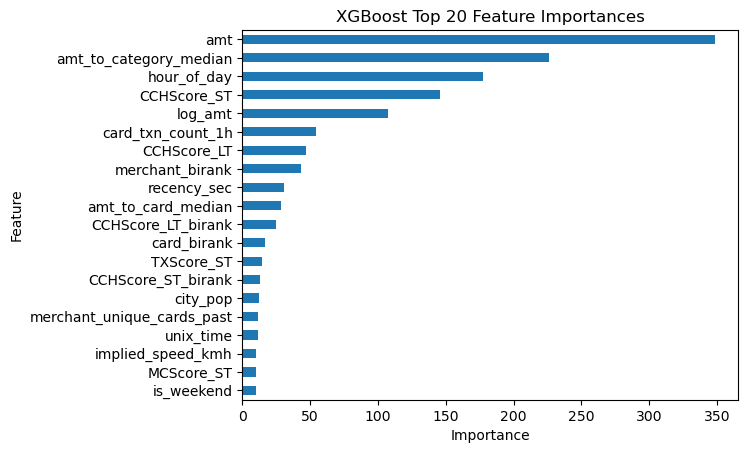

In [28]:
feat_importance = pd.DataFrame(model.get_score(importance_type='gain').items(), columns=['feature', 'importance'])

plt.figure(figsize=(10,8))
feat_importance.sort_values("importance", ascending=False).head(20)\
    .sort_values("importance")\
    .plot.barh(x="feature", y="importance", legend=False)
plt.title("XGBoost Top 20 Feature Importances")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()